In [1]:
import jax
print(f"JAX devices: {jax.devices()}")
print(f"Backend: {jax.default_backend()}")
assert jax.default_backend() == "gpu", "gpu not detected!"


JAX devices: [CudaDevice(id=0)]
Backend: gpu


In [2]:
from jax import config
config.update("jax_enable_x64", True)
config.update("jax_platform_name", "gpu")

import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
from jax import jit, vmap, value_and_grad
import jax
import os

import jaxley as jx
import jaxley.optimize.transforms as jt
from jaxley.channels import HH
from jaxley.synapses import IonotropicSynapse
from jaxley.connect import connect

import optax
import time as time

import pandas as pd

import os
import tempfile
from pathlib import Path
import json

### Multi-comp HH model setup

In [3]:
n_post_comp = 15
num_pre = 8
post_idx = num_pre # post cell index inside the network
Nsyn = num_pre

i_delay = 10.0    # ms
i_amp = 0.2   # nA
i_dur = 10.0   # ms
dt = 0.025  # ms
t_max = 50.0   # ms

base_amp = i_amp

syn_post_comp_indices = np.linspace(0, n_post_comp - 1, num_pre).astype(int)

def build_net():
    comp_pre = jx.Compartment()
    branch_pre = jx.Branch(comp_pre, ncomp=1)
    cell_pre = jx.Cell(branch_pre, parents=np.asarray([-1]))

    comp_post = jx.Compartment()
    branch_post = jx.Branch(comp_post, ncomp=n_post_comp)
    cell_post = jx.Cell(branch_post, parents=np.asarray([-1]))

    pre_cells = [cell_pre for _ in range(num_pre)]
    cells = pre_cells + [cell_post]
    net = jx.Network(cells)

    net.insert(HH())

    syn = IonotropicSynapse()
    for pre_i, comp_i in zip(range(num_pre), syn_post_comp_indices):
        connect(
            net.cell(pre_i).branch(0).comp(0),
            net.cell(post_idx).branch(0).comp(int(comp_i)),
            syn,
        )
    return net

def setup_recordings(net_obj):
    net_obj.delete_recordings()
    net_obj.cell(post_idx).branch(0).comp(0).record()  # syn 0 = soma
    for ci in syn_post_comp_indices:
        if int(ci) != 0:
            net_obj.cell(post_idx).branch(0).comp(int(ci)).record()
    return net_obj

net_analysis = build_net()


net_analysis = setup_recordings(net_analysis)

# net_analysis.IonotropicSynapse.set("IonotropicSynapse_gS", 5e-4) # code to update if needed 
net_analysis.IonotropicSynapse.edge("all").make_trainable("IonotropicSynapse_gS")
params_true = net_analysis.get_parameters()
print(f"Network: {net_analysis.nodes.shape[0]} compartments, "
      f"{net_analysis.edges.shape[0]} edges")
print(f"Number of synapses = {Nsyn}, syn_post_comp_indices = {syn_post_comp_indices}")




Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 8. Total number of trainable parameters: 8
Network: 23 compartments, 8 edges
Number of synapses = 8, syn_post_comp_indices = [ 0  2  4  6  8 10 12 14]


In [4]:
print("node columns:", list(net_analysis.nodes.columns))

cols = [c for c in net_analysis.nodes.columns]

print("showing cols:", cols)
display(net_analysis.nodes[cols].head(15))

node columns: ['local_cell_index', 'local_branch_index', 'local_comp_index', 'length', 'radius', 'axial_resistivity', 'capacitance', 'v', 'area', 'volume', 'resistive_load_in', 'resistive_load_out', 'x', 'y', 'z', 'global_cell_index', 'global_branch_index', 'global_comp_index', 'controlled_by_param', 'HH', 'HH_gNa', 'HH_gK', 'HH_gLeak', 'HH_eNa', 'HH_eK', 'HH_eLeak', 'HH_m', 'HH_h', 'HH_n']
showing cols: ['local_cell_index', 'local_branch_index', 'local_comp_index', 'length', 'radius', 'axial_resistivity', 'capacitance', 'v', 'area', 'volume', 'resistive_load_in', 'resistive_load_out', 'x', 'y', 'z', 'global_cell_index', 'global_branch_index', 'global_comp_index', 'controlled_by_param', 'HH', 'HH_gNa', 'HH_gK', 'HH_gLeak', 'HH_eNa', 'HH_eK', 'HH_eLeak', 'HH_m', 'HH_h', 'HH_n']


,local_cell_index,local_branch_index,local_comp_index,length,radius,axial_resistivity,capacitance,v,area,volume,...,HH,HH_gNa,HH_gK,HH_gLeak,HH_eNa,HH_eK,HH_eLeak,HH_m,HH_h,HH_n
0,0,0,0,10.0,1.0,5000.0,1.0,-70.0,62.831853,31.415927,...,True,0.12,0.036,0.0003,50.0,-77.0,-54.3,0.2,0.2,0.2
1,1,0,0,10.0,1.0,5000.0,1.0,-70.0,62.831853,31.415927,...,True,0.12,0.036,0.0003,50.0,-77.0,-54.3,0.2,0.2,0.2
2,2,0,0,10.0,1.0,5000.0,1.0,-70.0,62.831853,31.415927,...,True,0.12,0.036,0.0003,50.0,-77.0,-54.3,0.2,0.2,0.2
3,3,0,0,10.0,1.0,5000.0,1.0,-70.0,62.831853,31.415927,...,True,0.12,0.036,0.0003,50.0,-77.0,-54.3,0.2,0.2,0.2
4,4,0,0,10.0,1.0,5000.0,1.0,-70.0,62.831853,31.415927,...,True,0.12,0.036,0.0003,50.0,-77.0,-54.3,0.2,0.2,0.2
5,5,0,0,10.0,1.0,5000.0,1.0,-70.0,62.831853,31.415927,...,True,0.12,0.036,0.0003,50.0,-77.0,-54.3,0.2,0.2,0.2
6,6,0,0,10.0,1.0,5000.0,1.0,-70.0,62.831853,31.415927,...,True,0.12,0.036,0.0003,50.0,-77.0,-54.3,0.2,0.2,0.2
7,7,0,0,10.0,1.0,5000.0,1.0,-70.0,62.831853,31.415927,...,True,0.12,0.036,0.0003,50.0,-77.0,-54.3,0.2,0.2,0.2
8,8,0,0,10.0,1.0,5000.0,1.0,-70.0,62.831853,31.415927,...,True,0.12,0.036,0.0003,50.0,-77.0,-54.3,0.2,0.2,0.2
9,8,0,1,10.0,1.0,5000.0,1.0,-70.0,62.831853,31.415927,...,True,0.12,0.036,0.0003,50.0,-77.0,-54.3,0.2,0.2,0.2


### Simulation Setup

In [5]:
t_warm = 40    
i_delay_eff = t_warm + i_delay #start
t_max_eff = t_warm + t_max #end
T_keep = int(round(t_max/dt)) + 1
i0 = int(round(t_warm/dt))
print(f"Warmup: t_warm={t_warm} ms, i0={i0}, T_keep={T_keep}, "
      f"total sim = {t_max_eff} ms")

def simulate_analysis(params_phys, pattern):
    amps = base_amp * pattern
    currents = jx.datapoint_to_step_currents(
        i_delay=i_delay_eff, i_dur=i_dur,
        i_amp=amps, delta_t=dt, t_max=t_max_eff,
    )
    net_analysis.delete_stimuli()
    data_stimuli = None
    for i in range(num_pre):
        data_stimuli = (
            net_analysis.cell(i).branch(0).loc(0.0)
            .data_stimulate(currents[i], data_stimuli=data_stimuli)
        )
    traces = jx.integrate(net_analysis, params=params_phys,
                          data_stimuli=data_stimuli, delta_t=dt)

    # crop out warmup toreturn clean 0...50ms window
    return traces[:, i0:i0 + T_keep]

def simulate_soma(params_phys, pattern):
    return simulate_analysis(params_phys, pattern)[0]   # (T,)

batched_simulate_soma = vmap(simulate_soma, in_axes=(None, 0)) # get many traces at once 

def loss_and_traces(params_phys, pattern, target):
    raw_traces = simulate_analysis(params_phys, pattern)
    soma_pred = raw_traces[0]
    loss = jnp.mean((soma_pred - target) ** 2)
    return loss, raw_traces

vg_fn = jit(value_and_grad(loss_and_traces, argnums=0, has_aux=True))

def single_trial(params_phys, pattern, target):
    (loss, raw_traces), grads = vg_fn(params_phys, pattern, target)
    grad_w = grads[0]["IonotropicSynapse_gS"]       # (Nsyn,)
    return grad_w, raw_traces, loss

# batched over patterns (shared params)
batched_vg = jit(jax.vmap(
    jax.value_and_grad(loss_and_traces, argnums=0, has_aux=True),
    in_axes=(None, 0, 0),
))



Warmup: t_warm=40 ms, i0=1600, T_keep=2001, total sim = 90.0 ms


In [6]:
print(f"Params_true = {params_true}")

Params_true = [{'IonotropicSynapse_gS': Array([0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001],      dtype=float64)}]


In [7]:
gS_true = params_true[0]["IonotropicSynapse_gS"]
params_true = [{"IonotropicSynapse_gS": gS_true}]
transform = jx.ParamTransform([
    {"IonotropicSynapse_gS": jt.SigmoidTransform(1e-5, 1e-2)},
])

opt_params_true = transform.inverse(params_true)
key_learn = jax.random.PRNGKey(1)
sigma = 0.05  # 5% lognormal perturbation
gS_learned = jnp.clip(
    gS_true * jnp.exp(sigma * jax.random.normal(key_learn, (Nsyn,))),
    1e-5, 1e-2
)
params_analysis = [{"IonotropicSynapse_gS": gS_learned}]
gS_learned = params_analysis[0]["IonotropicSynapse_gS"]

print("gS_true:", gS_true)
print("gS_learned:", gS_learned)
print(f"max |diff|: {float(jnp.max(jnp.abs(gS_true - gS_learned))):.2e}")



gS_true: [0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001 0.0001]
gS_learned: [9.42504843e-05 9.94208316e-05 1.00867190e-04 1.04902940e-04
 9.59207643e-05 1.03514370e-04 1.00377964e-04 9.62495051e-05]
max |diff|: 5.75e-06


#### Pattern Visualization

In [8]:
patterns_zero = jnp.zeros(Nsyn,dtype=jnp.float64) # (8, 8)
print(f"\npatterns zero shape: {patterns_zero.shape}")
print(patterns_zero)

targets_zero = batched_simulate_soma(params_true, patterns_zero[None, :]) 
T = targets_zero.shape[1]                                   
t_arr = np.arange(T_keep) * dt

print(f"\ntargets_zero shape: {targets_zero.shape}")
print(f"T = {T},  dt = {dt} ms,  t_max = {t_max} ms")



patterns zero shape: (8,)
[0. 0. 0. 0. 0. 0. 0. 0.]

targets_zero shape: (1, 2001)
T = 2001,  dt = 0.025 ms,  t_max = 50.0 ms


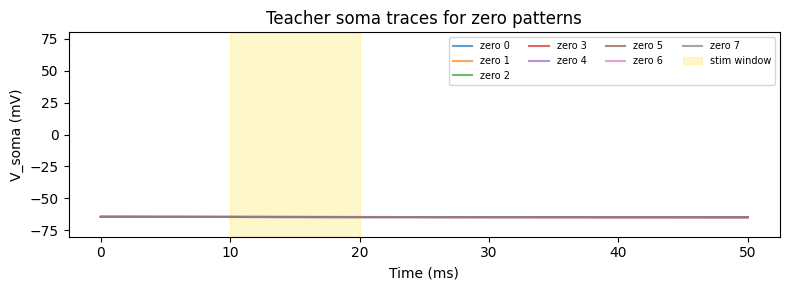

In [10]:
fig, ax = plt.subplots(figsize=(8, 3))
for p in range(Nsyn):
    ax.plot(t_arr, targets_zero[p], alpha=0.7, label=f"zero {p}")
ax.axvspan(i_delay, i_delay + i_dur, color="gold", alpha=0.2, label="stim window")
ax.set_ylim(-80, 80)
ax.set_xlabel("Time (ms)"); ax.set_ylabel("V_soma (mV)")
ax.set_title("Teacher soma traces for zero patterns")
ax.legend(fontsize=7, ncol=4)
plt.tight_layout(); plt.show()

In [11]:
patterns_onehot = jnp.eye(Nsyn, dtype=jnp.float64)   # (8, 8)
print(f"\npatterns_onehot shape: {patterns_onehot.shape}")
print(patterns_onehot)

targets_onehot = batched_simulate_soma(params_true, patterns_onehot)   # (8, T)
T = targets_onehot.shape[1]                                            # time axis
t_arr = np.arange(T_keep) * dt

print(f"\ntargets_onehot shape: {targets_onehot.shape}")
print(f"T = {T},  dt = {dt} ms,  t_max = {t_max} ms")

print("\n── Gradients (student params vs teacher targets) ──")
for p in range(Nsyn):
    grad_w, raw_traces, loss = single_trial(params_analysis, patterns_onehot[p], targets_onehot[p])
    vmax_err = float(jnp.max(jnp.abs(raw_traces[0] - targets_onehot[p])))
    print(f"pattern {p}: loss={float(loss):.3e}  max|v-target|={vmax_err:.3e}  grad={grad_w}")


patterns_onehot shape: (8, 8)
[[1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]]

targets_onehot shape: (8, 2001)
T = 2001,  dt = 0.025 ms,  t_max = 50.0 ms

── Gradients (student params vs teacher targets) ──
pattern 0: loss=7.718e-03  max|v-target|=2.375e-01  grad=[-2.69184291e+03 -1.07301620e+02 -5.21085721e+01 -2.55214582e+01
 -1.26293885e+01 -6.41332089e+00 -3.55899648e+00 -2.55471775e+00]
pattern 1: loss=1.696e-04  max|v-target|=2.438e-02  grad=[ -44.10251022 -191.47243512   -9.85663855   -4.78027774   -2.33160813
   -1.15590997   -0.61774702   -0.42877813]
pattern 2: loss=6.556e-05  max|v-target|=1.287e-02  grad=[-27.12856798 -12.93240105 -25.3945251   -2.92015668  -1.40168958
  -0.67804507  -0.34864315  -0.23338191]
pattern 3: loss=1.208e-04  max|v-target|=3.317e-02  grad=[-11.86792118  -5.77765455  -2.83841327  3

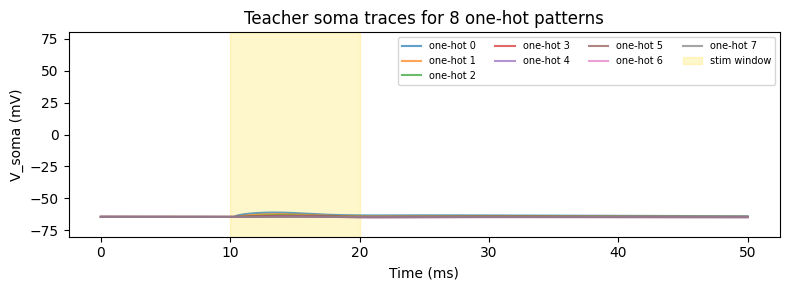

In [12]:
fig, ax = plt.subplots(figsize=(8, 3))
for p in range(Nsyn):
    ax.plot(t_arr, targets_onehot[p], alpha=0.7, label=f"one-hot {p}")
ax.axvspan(i_delay, i_delay + i_dur, color="gold", alpha=0.2, label="stim window")
ax.set_ylim(-80, 80)
ax.set_xlabel("Time (ms)"); ax.set_ylabel("V_soma (mV)")
ax.set_title("Teacher soma traces for 8 one-hot patterns")
ax.legend(fontsize=7, ncol=4)
plt.tight_layout(); plt.show()

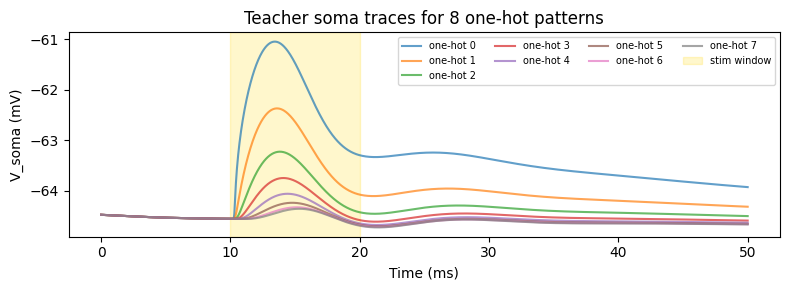

In [13]:
fig, ax = plt.subplots(figsize=(8, 3))
for p in range(Nsyn):
    ax.plot(t_arr, targets_onehot[p], alpha=0.7, label=f"one-hot {p}")
ax.axvspan(i_delay, i_delay + i_dur, color="gold", alpha=0.2, label="stim window")
ax.set_xlabel("Time (ms)"); ax.set_ylabel("V_soma (mV)")
ax.set_title("Teacher soma traces for 8 one-hot patterns")
ax.legend(fontsize=7, ncol=4)
plt.tight_layout(); plt.show()

### Optional hyperparameter tuning: minimal synaptic weight and pattern to create somatic action potential

In [13]:
# def has_somatic_ap(v_soma: jnp.ndarray, dt: float,
#                    v_overshoot_th: float = 0.0,
#                    dvdt_th: float = 30.0,
#                    v_floor_for_dvdt: float = -20.0) -> jnp.bool_:
#     # condition A: overshoot
#     overshoot = jnp.any(v_soma >= v_overshoot_th)

#     # condition B: fast upstroke + sufficiently depolarized
#     dvdt = jnp.diff(v_soma) / dt  # mV/ms
#     fast_up = jnp.any((dvdt >= dvdt_th) & (v_soma[1:] >= v_floor_for_dvdt))

#     return overshoot | fast_up

# batched_has_somatic_ap = jit(vmap(has_somatic_ap, in_axes=(0, None, None, None, None)))

In [14]:
# pattern_all_on  = jnp.ones((Nsyn,), dtype=jnp.float32)

# def patterns_of_weight(k: int) -> jnp.ndarray:
#     from itertools import combinations
#     idxs = []
#     for comb in combinations(range(Nsyn), k):
#         p = np.zeros((Nsyn,), dtype=np.float32)
#         p[list(comb)] = 1.0
#         idxs.append(p)
#     return jnp.asarray(np.stack(idxs, axis=0))

# # identify which synapse is on soma (comp 0)
# soma_syn_mask = (syn_post_comp_indices == 0)
# # if multiple happen to be 0 (unlikely), this still works.
# soma_onehot_indices = np.where(soma_syn_mask)[0].tolist()

# def eval_gS(gS_value: float):
#     # set ALL synapses to this gS (same as you do)
#     net_analysis.IonotropicSynapse.set("IonotropicSynapse_gS", float(gS_value))

#     params = net_analysis.get_parameters()
#     gS_vec = params[0]["IonotropicSynapse_gS"]
#     params_phys = [{"IonotropicSynapse_gS": gS_vec}]

#     # all-on
#     v_all = simulate_soma(params_phys, pattern_all_on)
#     all_on_ap = bool(has_somatic_ap(v_all, dt))

#     # onehots
#     v_1 = batched_simulate_soma(params_phys, patterns_onehot)  # (8,T)
#     onehot_ap = batched_has_somatic_ap(v_1, dt, 0.0, 30.0, -20.0)  # (8,)
#     onehot_ap = jnp.asarray(onehot_ap)

#     n_onehot = int(jnp.sum(onehot_ap))
#     any_onehot = bool(jnp.any(onehot_ap))

#     # minimal k
#     min_k = None
#     for k in range(1, Nsyn + 1):
#         Pk = patterns_of_weight(k)
#         v_k = batched_simulate_soma(params_phys, Pk)
#         ap_k = batched_has_somatic_ap(v_k, dt, 0.0, 30.0, -20.0)
#         if bool(jnp.any(ap_k)):
#             min_k = k
#             break

#     return {
#         "gS": float(gS_value),
#         "all_on_ap": all_on_ap,
#         "onehot_ap": onehot_ap,   # boolean (8,)
#         "n_onehot_ap": n_onehot,
#         "min_k": min_k,
#     }

# # run sweep
# gS_sweep = np.geomspace(1e-4, 5e-4, 9)
# results = [eval_gS(g) for g in gS_sweep]

# for r in results:
#     print(f"gS={r['gS']:.2e} | all-on AP={r['all_on_ap']} | "
#           f"onehot AP={r['n_onehot_ap']}/8 | min_k={r['min_k']}")

# # pick rule A: strict (no onehot AP at all)
# picked_strict = None
# for r in results:
#     if r["all_on_ap"] and (r["n_onehot_ap"] == 0) and (r["min_k"] is not None) and (2 <= r["min_k"] <= 5):
#         picked_strict = r
#         break

# # pick rule B: allow soma-onehot AP only
# picked_allow_soma = None
# for r in results:
#     oh = np.array(r["onehot_ap"], dtype=bool)
#     ok = True
#     for i in range(Nsyn):
#         if oh[i] and (i not in soma_onehot_indices):  # any non-soma onehot AP -> reject
#             ok = False
#             break
#     if r["all_on_ap"] and ok and (r["min_k"] is not None) and (2 <= r["min_k"] <= 5):
#         picked_allow_soma = r
#         break

# print("\nPicked (strict):", None if picked_strict is None else picked_strict["gS"])
# print("Picked (allow soma onehot):", None if picked_allow_soma is None else picked_allow_soma["gS"])

In [15]:
# def patterns_of_weight_k(N, k, dtype=np.float64):
#     pats = []
#     from itertools import combinations
#     for comb in combinations(range(N), k):
#         p = np.zeros((N,), dtype=dtype)
#         p[list(comb)] = 1.0
#         pats.append(p)
#     return jnp.asarray(np.stack(pats, axis=0))

# patterns_3hot = patterns_of_weight_k(Nsyn, 3)   # (56, 8)
# print("patterns_3hot shape:", patterns_3hot.shape)

# # ---- simulate soma for all 3-hot patterns
# targets_3hot = batched_simulate_soma(params_true, patterns_3hot)  # (56, T)
# T = targets_3hot.shape[1]
# t_arr = np.arange(T_keep) * dt

# print("targets_3hot shape:", targets_3hot.shape)

# # ---- (optional) compute which 3-hot patterns cause somatic AP (using your AP detector)
# ap_3hot = jnp.array([has_somatic_ap(targets_3hot[i], dt) for i in range(targets_3hot.shape[0])])
# print(f"# somatic APs in 3-hot set: {int(ap_3hot.sum())} / {targets_3hot.shape[0]}")

# # ---- plot: overlay all traces (AP ones thicker)
# fig, ax = plt.subplots(figsize=(9, 3.5))

# for i in range(targets_3hot.shape[0]):
#     if bool(ap_3hot[i]):
#         ax.plot(t_arr, np.array(targets_3hot[i]), alpha=0.9, lw=1.5)
#     else:
#         ax.plot(t_arr, np.array(targets_3hot[i]), alpha=0.15, lw=1.0)

# ax.axvspan(i_delay, i_delay + i_dur, color="gold", alpha=0.2, label="stim window")
# ax.set_ylim(-80, 80)
# ax.set_xlabel("Time (ms)")
# ax.set_ylabel("V_soma (mV)")
# ax.set_title("Teacher soma traces for all 56 three-hot patterns (thick = AP)")
# plt.tight_layout()
# plt.show()

# # ---- (optional) show which 3-hot patterns spiked (by indices)
# spiking_idx = np.where(np.array(ap_3hot, dtype=bool))[0]
# print("Spiking 3-hot pattern indices:", spiking_idx)

# # print the actual active synapse indices for each spiking pattern
# for i in spiking_idx[:]:  # show first 10
#     on = np.where(np.array(patterns_3hot[i]) > 0.5)[0]
#     print(f"pattern {i}: on synapses {on}")

### Gradient Factorization

Because loss is:
```
L = mean_t (V_soma(t) - target(t))^2
```

the "credit/adjoint" term is analytic:

$$\frac{\partial L}{\partial V_{\text{soma}}(t)} = \frac{2}{T}\,(V_{\text{soma}}(t) - \text{target}(t))$$

We have:
1. autograd gradient `dL/dg` (what you already do)
2. Jacobian $J(t,i) = \partial V(t) / \partial g_i$
3. factorized gradient $J^\top \cdot (dL/dV)$
4. verify they match

In [23]:
ON_IDXS = jnp.array([1, 6, 7], dtype=jnp.int32)

def make_khot_pattern(on_idxs, Nsyn, dtype=jnp.float32):
    p = jnp.zeros((Nsyn,), dtype=dtype)
    return p.at[on_idxs].set(1.0)

pattern_167 = make_khot_pattern(ON_IDXS, Nsyn)              # (Nsyn,)
patterns_train = pattern_167[None, :]    
print(patterns_train)
print(pattern_167)                   # (P=1, Nsyn)

# teacher target for this ONE pattern (shape (P=1, T_keep))
targets_train = batched_simulate_soma(params_true, patterns_train)  # (1, T_keep)

[[0. 1. 0. 0. 0. 0. 1. 1.]]
[0. 1. 0. 0. 0. 0. 1. 1.]


In [33]:
net_train = build_net()
net_train.delete_recordings()

net_train.cell(post_idx).branch(0).comp(0).record()

for ci in syn_post_comp_indices:
    if int(ci) != 0:
        net_train.cell(post_idx).branch(0).comp(int(ci)).record()

net_train.IonotropicSynapse.edge("all").make_trainable("IonotropicSynapse_gS")

train_transform = jx.ParamTransform([
    {"IonotropicSynapse_gS": jt.SigmoidTransform(1e-5, 1e-2)},
])

def sim_all_train(params_phys, pattern):
    amps = base_amp * pattern
    currents = jx.datapoint_to_step_currents(
        i_delay=i_delay_eff, i_dur=i_dur, i_amp=amps, delta_t=dt, t_max=t_max_eff,
    )
    net_train.delete_stimuli()
    data_stimuli = None
    for i in range(num_pre):
        data_stimuli = (
            net_train.cell(i).branch(0).loc(0.0)
            .data_stimulate(currents[i], data_stimuli=data_stimuli)
        )
    traces = jx.integrate(net_train, params=params_phys, data_stimuli=data_stimuli, delta_t=dt)
    return traces[:, i0:i0 + T_keep]   # (n_sites, T_keep)

def sim_soma_train(params_phys, pattern):
    return sim_all_train(params_phys, pattern)[0]          # (T_keep,)

batched_soma_train = vmap(sim_soma_train, in_axes=(None, 0))      # (params_phys, P) -> (P,T)
batched_all_train  = vmap(sim_all_train,  in_axes=(None, 0))      # (params_phys, P) -> (P,n_sites,T)

def train_loss_batch(opt_params, pats, tgts):
    params_phys = train_transform.forward(opt_params)
    preds = batched_soma_train(params_phys, pats)          # (P, T_keep)
    return jnp.mean((preds - tgts) ** 2)

train_lr = 0.05
train_optimizer = optax.adam(train_lr)

@jit
def train_step(opt_params, opt_state, pats, tgts):
    loss, grads = jax.value_and_grad(train_loss_batch)(
        opt_params, pats, tgts
    )
    updates, new_state = train_optimizer.update(grads, opt_state, opt_params)
    new_params = optax.apply_updates(opt_params, updates)
    return new_params, new_state, loss



Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 8. Total number of trainable parameters: 8


In [39]:
def soma_from_gS_train(gS_vec, pattern):
    params_phys = [{"IonotropicSynapse_gS": gS_vec}]
    return sim_soma_train(params_phys, pattern)            # (T_keep,)

# jacobian: dV_soma(t)/dgS_i for ONE pattern -> (T_keep, Nsyn)
J_soma_wrt_gS = jit(jax.jacfwd(soma_from_gS_train, argnums=0))

# vectorize Jacobian over patterns: (P,T,Nsyn)
batched_J = jit(vmap(lambda pat, gS: J_soma_wrt_gS(gS, pat), in_axes=(0, None)))


In [40]:
def trial_loss_and_pred(gS_vec, pattern, target):
    pred = soma_from_gS_train(gS_vec, pattern)              # (T,)
    loss = jnp.mean((pred - target) ** 2)                   # scalar
    return loss, pred

# per-pattern full gradient dL/dgS (P,Nsyn) + loss (P,) + pred soma (P,T)
trial_vg = jit(
    vmap(jax.value_and_grad(trial_loss_and_pred, argnums=0, has_aux=True),
         in_axes=(None, 0, 0))
)

In [41]:
def eval_params_on_patterns(params_phys, pats, tgts):
    """
    Returns dict with:
      losses: (P,)
      traces_all:(P,n_sites,T_keep)
      grad_full: (P,Nsyn)
      J:(P,T_keep,Nsyn)
      grad_fact:  (P,Nsyn)
      max_rel_err: scalar sanity for factorization match
    """
    gS_vec = params_phys[0]["IonotropicSynapse_gS"]          # (Nsyn,)

    # full grads per pattern
    ((losses, preds_soma), grads_full) = trial_vg(gS_vec, pats, tgts)   # grads_full (P,Nsyn)

    # full recorded traces (soma + dend sites)
    traces_all = batched_all_train(params_phys, pats)       # (P,n_sites,T)

    # jacobians per pattern
    J = batched_J(pats, gS_vec)                              # (P,T,Nsyn)

    # factorization per pattern: grad_fact = J^T @ dL/dV, with dL/dV = 2/T*(pred-target)
    T = preds_soma.shape[1]
    dL_dV = (2.0 / T) * (preds_soma - tgts)                  # (P,T)
    grad_fact = jnp.einsum("ptn,pt->pn", J, dL_dV)            # (P,Nsyn)

    # sanity: compare per-pattern max relative mismatch
    absdiff = jnp.max(jnp.abs(grads_full - grad_fact))
    denom = jnp.max(jnp.abs(grads_full)) + 1e-12
    max_rel_err = absdiff / denom

    return dict(
        losses=losses,
        traces_all=traces_all,
        grad_full=grads_full,
        J=J,
        grad_fact=grad_fact,
        max_rel_err=max_rel_err,
        gS_vec=gS_vec,
    )

In [42]:
def train_one_seed_adaptive(
    seed,
    patterns_train,
    targets_train,
    *,
    checkpoints=(10, 25, 50, 75, 100),
    loss_tol=1e-8,
    max_steps=500,
    chunk_steps=50,
    log_every=10,
):

    key = jax.random.PRNGKey(seed)
    key, subkey = jax.random.split(key)

    gS0 = jnp.clip(
        1e-4 * jnp.exp(0.15 * jax.random.normal(subkey, (Nsyn,))),
        1e-5, 1e-2,
    )
    params0 = [{"IonotropicSynapse_gS": gS0}]
    opt_params = train_transform.inverse(params0)
    opt_state = train_optimizer.init(opt_params)

    ckpt_set = set(checkpoints)
    ckpt_params = {} # step -> params_phys
    loss_log = []

    step = 0
    loss = jnp.inf

    while (step < max_steps) and (float(loss) > loss_tol):
        # do chunk_steps more updates (or until max_steps)
        n_inner = min(chunk_steps, max_steps - step)
        for _ in range(n_inner):
            step += 1
            opt_params, opt_state, loss = train_step(opt_params, opt_state, patterns_train, targets_train)

            if (step % log_every == 0) or (step in ckpt_set) or (step == max_steps):
                loss_log.append((step, float(loss)))

            if step in ckpt_set:
                ckpt_params[step] = train_transform.forward(opt_params)

    final_params = train_transform.forward(opt_params)
    stopped_reason = "tol" if float(loss) <= loss_tol else "max_steps"

    return ckpt_params, final_params, {
        "seed": seed,
        "stopped_reason": stopped_reason,
        "steps": step,
        "final_loss": float(loss),
        "losses": loss_log,
    }



In [43]:
seed0 = 0
checkpoints_small = (10, 25, 50, 75, 100)
ckpt_params0, final_params0, log0 = train_one_seed_adaptive(
    seed0,
    patterns_train,
    targets_train,
    checkpoints=checkpoints_small,
    loss_tol=1e-8,
    max_steps=200,
    chunk_steps=50,
    log_every=10,
)

print(f"seed={seed0}  stopped={log0['stopped_reason']}  steps={log0['steps']}  final_loss={log0['final_loss']:.3e}")
print("loss log (last 10):", log0["losses"][-10:])

# evaluate factorization sanity at final (and at checkpoints if present)
final_eval0 = eval_params_on_patterns(final_params0, patterns_train, targets_train)
print(f"factorization rel err (final): {float(final_eval0['max_rel_err']):.3e}")

for c in checkpoints_small:
    if c in ckpt_params0:
        ev = eval_params_on_patterns(ckpt_params0[c], patterns_train, targets_train)
        print(f"  step {c:3d}: loss={float(ev['losses'].mean()):.3e}  rel_err={float(ev['max_rel_err']):.3e}")


seed=0  stopped=max_steps  steps=200  final_loss=2.454e-03
loss log (last 10): [(110, 0.0052417420702618265), (120, 0.0038554790298204584), (130, 0.0032109385847969153), (140, 0.002919361079699231), (150, 0.002819589434891524), (160, 0.0027224468688807355), (170, 0.002636319327772616), (180, 0.0025682893832195425), (190, 0.0025082181645641253), (200, 0.0024539474017657567)]
factorization rel err (final): 3.119e-11
  step  10: loss=2.079e+00  rel_err=6.337e-11
  step  25: loss=3.526e-01  rel_err=5.691e-13
  step  50: loss=5.876e-01  rel_err=1.082e-12
  step  75: loss=3.183e-02  rel_err=2.609e-13
  step 100: loss=3.669e-03  rel_err=1.310e-12


In [ ]:
# def run_many_seeds_one_pattern(
#     S,
#     patterns_train,
#     targets_train,
#     *,
#     checkpoints=(10, 25, 50, 75, 100),
#     n_steps=None,          # if None, uses max(checkpoints)
# ):
#     P = patterns_train.shape[0]
#     if n_steps is None:
#         n_steps = int(max(checkpoints))

#     tmp_tr = _batched_all_train([{"IonotropicSynapse_gS": params_true[0]["IonotropicSynapse_gS"]}], patterns_train)
#     n_sites = int(tmp_tr.shape[1])

#     # allocate per-checkpoint arrays
#     VALL_ckpt = {c: np.zeros((S, P, n_sites, T_keep), dtype=np.float32) for c in checkpoints}
#     LOSS_ckpt = {c: np.zeros((S, P),               dtype=np.float32) for c in checkpoints}
#     GRADS_ckpt = {c: np.zeros((S, P, Nsyn),         dtype=np.float32) for c in checkpoints}
#     JALL_ckpt = {c: np.zeros((S, P, T_keep, Nsyn), dtype=np.float32) for c in checkpoints}
#     GRADFACT_ckpt  = {c: np.zeros((S, P, Nsyn),         dtype=np.float32) for c in checkpoints}
#     gS_ckpt        = {c: np.zeros((S, Nsyn),            dtype=np.float32) for c in checkpoints}
#     RELERR_ckpt    = {c: np.zeros((S,),                 dtype=np.float32) for c in checkpoints}

#     train_logs = []

#     print(f"\n=== ONE pattern × MANY seeds ===")
#     print(f"S={S}  steps={n_steps}  checkpoints={checkpoints}  P={P}  T_keep={T_keep}\n")

#     t_start = time.time()
#     for s in range(S):
#         t_seed = time.time()

#         ckpt_params_s, final_params_s, log_s = train_one_seed_adaptive(
#             s, patterns_train, targets_train,
#             checkpoints=checkpoints,
#             loss_tol=-1.0,            # disables tol stopping (always runs to max_steps)
#             max_steps=n_steps,
#             chunk_steps=n_steps,      # do it in one go
#             log_every=max(1, n_steps // 5),
#         )
#         train_logs.append(log_s)

#         for c in checkpoints:
#             params_c = ckpt_params_s[c]
#             ev = eval_params_on_patterns(params_c, patterns_train, targets_train)

#             gS_ckpt[c][s]       = np.asarray(ev["gS_vec"], dtype=np.float32)
#             VALL_ckpt[c][s]     = np.asarray(ev["traces_all"], dtype=np.float32)
#             LOSS_ckpt[c][s]     = np.asarray(ev["losses"], dtype=np.float32)
#             GRADS_ckpt[c][s]    = np.asarray(ev["grad_full"], dtype=np.float32)
#             JALL_ckpt[c][s]     = np.asarray(ev["J"], dtype=np.float32)
#             GRADFACT_ckpt[c][s] = np.asarray(ev["grad_fact"], dtype=np.float32)
#             RELERR_ckpt[c][s]   = float(ev["max_rel_err"])

#         if (s % 5 == 0) or (s == S - 1):
#             losses_str = "  ".join(f"step{c}={LOSS_ckpt[c][s].mean():.3e}" for c in checkpoints)
#             dt_seed = time.time() - t_seed
#             print(f"seed {s:3d}/{S}  {losses_str}  relerr@last={RELERR_ckpt[checkpoints[-1]][s]:.2e}  ({dt_seed:.1f}s)")

#     elapsed = time.time() - t_start
#     print(f"\nDone: {S} seeds in {elapsed:.1f}s  ({elapsed / S:.1f}s/seed)")
#     print("Final-loss range:",
#           f"[{min(l['final_loss'] for l in train_logs):.3e}, {max(l['final_loss'] for l in train_logs):.3e}]")

#     for c in checkpoints:
#         print(f"  step {c:3d}: mean loss={LOSS_ckpt[c].mean():.3e}  "
#               f"mean relerr={RELERR_ckpt[c].mean():.2e}  "
#               f"mean gS std={gS_ckpt[c].std(axis=0).mean():.2e}")

#     return dict(
#         VALL_ckpt=VALL_ckpt,
#         LOSS_ckpt=LOSS_ckpt,
#         GRADS_ckpt=GRADS_ckpt,
#         JALL_ckpt=JALL_ckpt,
#         GRADFACT_ckpt=GRADFACT_ckpt,
#         gS_ckpt=gS_ckpt,
#         RELERR_ckpt=RELERR_ckpt,
#         train_logs=train_logs,
#     )

In [28]:
# S = 20
# checkpoints = (10, 25, 50, 75, 100)
# out = run_many_seeds_one_pattern(S, patterns_train, targets_train, checkpoints=checkpoints)


=== ONE pattern × MANY seeds ===
S=20  steps=100  checkpoints=(10, 25, 50, 75, 100)  P=1  T_keep=2001

seed   0/20  step10=2.079e+00  step25=3.526e-01  step50=5.876e-01  step75=3.183e-02  step100=3.669e-03  relerr@last=1.31e-12  (161.7s)
seed   5/20  step10=4.553e+01  step25=1.104e+00  step50=9.444e-01  step75=2.545e-02  step100=2.603e-04  relerr@last=3.41e-13  (161.8s)
seed  10/20  step10=1.098e+01  step25=4.146e+00  step50=2.089e-01  step75=2.117e-02  step100=8.311e-03  relerr@last=6.45e-12  (162.0s)
seed  15/20  step10=2.362e+02  step25=2.358e+02  step50=2.335e+02  step75=2.334e+02  step100=2.334e+02  relerr@last=1.05e-13  (160.6s)
seed  19/20  step10=1.541e+02  step25=6.281e+00  step50=4.108e+00  step75=4.035e-01  step100=3.684e-02  relerr@last=4.72e-13  (163.4s)

Done: 20 seeds in 3223.9s  (161.2s/seed)
Final-loss range: [1.562e-03, 2.337e+02]
  step  10: mean loss=8.301e+01  mean relerr=3.22e-11  mean gS std=1.44e-05
  step  25: mean loss=4.238e+01  mean relerr=2.86e-12  mean gS

In [49]:
def atomic_save_npz(path: Path, **arrays):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    # Create a temp file in the same directory, with a .npz suffix
    fd, tmp_name = tempfile.mkstemp(dir=path.parent, suffix=".npz")
    os.close(fd)
    tmp_path = Path(tmp_name)

    try:
        np.savez_compressed(tmp_path, **arrays)  # tmp_path already ends with .npz
        os.replace(tmp_path, path)               # atomic rename on same filesystem
    except Exception:
        # Cleanup temp file if something goes wrong
        try:
            if tmp_path.exists():
                tmp_path.unlink()
        finally:
            raise

In [50]:
def run_many_seeds_one_pattern_save_per_seed(
    S,
    patterns_train,
    targets_train,
    *,
    checkpoints=(10,25,50,75,100, 125, 150),
    n_steps=None,
    outdir=None,
    resume=True,
    keep_in_memory=True,
):
    P = patterns_train.shape[0]
    if n_steps is None:
        n_steps = int(max(checkpoints))

    if outdir is None:
        outdir = make_run_dir(run_name=f"onepat_167_S{S}_steps{n_steps}")
    else:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)

    # save meta once
    meta = dict(
        S=int(S),
        P=int(P),
        checkpoints=list(checkpoints),
        n_steps=int(n_steps),
        dt=float(dt),
        T_keep=int(T_keep),
        pattern=np.asarray(patterns_train[0]).tolist(),
    )
    with open(outdir / "meta.json", "w") as f:
        json.dump(meta, f, indent=2)

    # determine n_sites once
    tmp_tr = batched_all_train([{"IonotropicSynapse_gS": params_true[0]["IonotropicSynapse_gS"]}], patterns_train)
    n_sites = int(tmp_tr.shape[1])

    # keep full arrays in RAM
    if keep_in_memory:
        VALL_ckpt = {c: np.zeros((S, P, n_sites, T_keep), dtype=np.float32) for c in checkpoints}
        LOSS_ckpt = {c: np.zeros((S, P),               dtype=np.float32) for c in checkpoints}
        GRADS_ckpt = {c: np.zeros((S, P, Nsyn),        dtype=np.float32) for c in checkpoints}
        JALL_ckpt = {c: np.zeros((S, P, T_keep, Nsyn), dtype=np.float32) for c in checkpoints}
        GRADFACT_ckpt = {c: np.zeros((S, P, Nsyn),     dtype=np.float32) for c in checkpoints}
        gS_ckpt = {c: np.zeros((S, Nsyn),              dtype=np.float32) for c in checkpoints}
        RELERR_ckpt = {c: np.zeros((S,),               dtype=np.float32) for c in checkpoints}
        train_logs = [None] * S
    else:
        VALL_ckpt = LOSS_ckpt = GRADS_ckpt = JALL_ckpt = None
        GRADFACT_ckpt = gS_ckpt = RELERR_ckpt = None
        train_logs = None

    print(f"\nSaving per-seed files to: {outdir}")
    print(f"S={S}, checkpoints={checkpoints}, steps={n_steps}, P={P}, n_sites={n_sites}, T={T_keep}\n")

    for s in range(S):
        seed_path = outdir / f"seed_{s:03d}.npz"
        log_path  = outdir / f"seed_{s:03d}_log.json"

        if resume and seed_path.exists():
            print(f"seed {s:3d}: exists -> skip")
            # if keeping in memory, you can also load it back in here
            continue

        # train this seed
        ckpt_params_s, final_params_s, log_s = train_one_seed_adaptive(
            s, patterns_train, targets_train,
            checkpoints=checkpoints,
            loss_tol=-1.0,
            max_steps=n_steps,
            chunk_steps=n_steps,
            log_every=max(1, n_steps // 5),
        )

        # compute and store arrays for this seed (across checkpoints)
        save_dict = {}
        for c in checkpoints:
            params_c = ckpt_params_s[c]
            ev = eval_params_on_patterns(params_c, patterns_train, targets_train)

            save_dict[f"gS_{c}"]       = np.asarray(ev["gS_vec"], dtype=np.float32)              # (Nsyn,)
            save_dict[f"VALL_{c}"]     = np.asarray(ev["traces_all"], dtype=np.float32)         # (P,n_sites,T)
            save_dict[f"LOSS_{c}"]     = np.asarray(ev["losses"], dtype=np.float32)             # (P,)
            save_dict[f"GRADS_{c}"]    = np.asarray(ev["grad_full"], dtype=np.float32)          # (P,Nsyn)
            save_dict[f"JALL_{c}"]     = np.asarray(ev["J"], dtype=np.float32)                  # (P,T,Nsyn)
            save_dict[f"GRADFACT_{c}"] = np.asarray(ev["grad_fact"], dtype=np.float32)          # (P,Nsyn)
            save_dict[f"RELERR_{c}"]   = np.asarray(float(ev["max_rel_err"]), dtype=np.float32) # scalar

            # if also keeping in memory, fill the big arrays
            if keep_in_memory:
                gS_ckpt[c][s]        = save_dict[f"gS_{c}"]
                VALL_ckpt[c][s]      = save_dict[f"VALL_{c}"]
                LOSS_ckpt[c][s]      = save_dict[f"LOSS_{c}"]
                GRADS_ckpt[c][s]     = save_dict[f"GRADS_{c}"]
                JALL_ckpt[c][s]      = save_dict[f"JALL_{c}"]
                GRADFACT_ckpt[c][s]  = save_dict[f"GRADFACT_{c}"]
                RELERR_ckpt[c][s]    = float(save_dict[f"RELERR_{c}"])

        # save seed file atomically (crash-safe)
        atomic_save_npz(seed_path, **save_dict)

        # save log as json
        with open(log_path, "w") as f:
            json.dump(log_s, f, indent=2)

        if keep_in_memory:
            train_logs[s] = log_s

        print(f"seed {s:3d}: saved {seed_path.name}")

    if keep_in_memory:
        return dict(
            VALL_ckpt=VALL_ckpt,
            LOSS_ckpt=LOSS_ckpt,
            GRADS_ckpt=GRADS_ckpt,
            JALL_ckpt=JALL_ckpt,
            GRADFACT_ckpt=GRADFACT_ckpt,
            gS_ckpt=gS_ckpt,
            RELERR_ckpt=RELERR_ckpt,
            train_logs=train_logs,
            outdir=str(outdir),
        )
    else:
        return dict(outdir=str(outdir))

In [53]:
S = 30
checkpoints = (10,25,50,75,100, 125, 150)

out = run_many_seeds_one_pattern_save_per_seed(
    S, patterns_train, targets_train,
    checkpoints=checkpoints,
    keep_in_memory=True,  
    resume=True,
)
print("run dir:", out["outdir"])


Saving per-seed files to: outputs/onepat_167_S30_steps150
S=30, checkpoints=(10, 25, 50, 75, 100, 125, 150), steps=150, P=1, n_sites=8, T=2001

seed   0: exists -> skip
seed   1: exists -> skip
seed   2: exists -> skip
seed   3: exists -> skip
seed   4: exists -> skip
seed   5: exists -> skip
seed   6: exists -> skip
seed   7: exists -> skip
seed   8: exists -> skip
seed   9: exists -> skip
seed  10: exists -> skip
seed  11: exists -> skip
seed  12: exists -> skip
seed  13: exists -> skip
seed  14: exists -> skip
seed  15: exists -> skip
seed  16: exists -> skip
seed  17: exists -> skip
seed  18: exists -> skip
seed  19: exists -> skip
seed  20: exists -> skip
seed  21: exists -> skip
seed  22: exists -> skip
seed  23: exists -> skip
seed  24: exists -> skip
seed  25: exists -> skip
seed  26: exists -> skip
seed  27: exists -> skip
seed  28: exists -> skip
seed  29: exists -> skip
run dir: outputs/onepat_167_S30_steps150


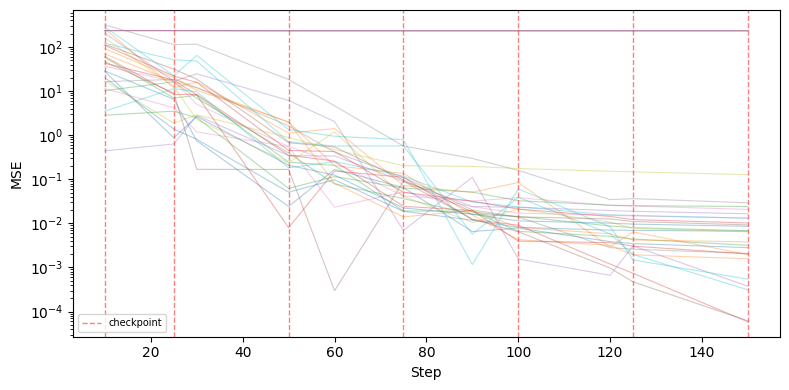

In [60]:
def load_train_logs(outdir, S):
    outdir = Path(outdir)
    logs = []
    for s in range(S):
        lp = outdir / f"seed_{s:03d}_log.json"
        with open(lp, "r") as f:
            logs.append(json.load(f))
    return logs

def plot_training_curves(train_logs, checkpoints):
    fig, ax = plt.subplots(figsize=(8,4))
    for log_s in train_logs:
        steps, losses = zip(*log_s["losses"])
        ax.plot(steps, losses, alpha=0.35, lw=0.8)
    for i,c in enumerate(checkpoints):
        ax.axvline(c, color="red", ls="--", lw=1, alpha=0.5, label="checkpoint" if i==0 else None)
    ax.set_yscale("log")
    ax.set_xlabel("Step"); ax.set_ylabel("MSE"); ax.legend(fontsize=7)
    plt.tight_layout()
    return fig

outdir = Path("outputs/onepat_167_S30_steps150")
train_logs = load_train_logs(outdir, S=30)
fig = plot_training_curves(train_logs, checkpoints)
fig.savefig(outdir / "training_curves.png", dpi=200, bbox_inches="tight")
plt.show()

In [66]:
def load_gS_ckpt_from_seed_npz(outdir, S, checkpoints, Nsyn):
    outdir = Path(outdir)
    gS_ckpt = {c: np.zeros((S, Nsyn), dtype=np.float32) for c in checkpoints}

    for s in range(S):
        seed_path = outdir / f"seed_{s:03d}.npz"
        d = np.load(seed_path)
        for c in checkpoints:
            gS_ckpt[c][s] = d[f"gS_{c}"]  # (Nsyn,)
    return gS_ckpt

In [67]:
def plot_gS_ckpt(gS_ckpt, gS_true, checkpoints, S, Nsyn, *, logy=False):
    gS_true = np.asarray(gS_true).reshape(-1)
    if gS_true.size == 1:
        gS_true_vec = np.full(Nsyn, float(gS_true[0]))
    else:
        assert gS_true.size == Nsyn, f"gS_true must be scalar or length {Nsyn}, got {gS_true.size}"
        gS_true_vec = gS_true

    n_ckpt = len(checkpoints)
    fig, axes = plt.subplots(1, n_ckpt, figsize=(5 * n_ckpt, 3.5),
                             sharey=True, constrained_layout=True)
    if n_ckpt == 1:
        axes = [axes]

    for ci, c in enumerate(checkpoints):
        ax = axes[ci]

        # scatter learned gS across seeds
        for i in range(Nsyn):
            ax.scatter(
                np.full(S, i) + 0.08 * np.random.randn(S),
                gS_ckpt[c][:, i],
                s=12, alpha=0.6, zorder=2
            )

        # true per-synapse markers
        ax.scatter(
            np.arange(Nsyn),
            gS_true_vec,
            color="red",
            marker="_",
            s=500,
            zorder=10,
            label="gS_true" if ci == 0 else None
        )

        ax.set_xlabel("Synapse index")
        if ci == 0:
            ax.set_ylabel("Learned gS")
        ax.set_title(f"Step {c}")
        if logy:
            ax.set_yscale("log")
        if ci == 0:
            ax.legend(fontsize=7)

    fig.suptitle(f"Learned gS distribution across {S} seeds", fontsize=12)
    return fig

In [68]:
outdir = Path("outputs/onepat_167_S30_steps150")
gS_ckpt_disk = load_gS_ckpt_from_seed_npz(outdir, S=30, checkpoints=checkpoints, Nsyn=Nsyn)

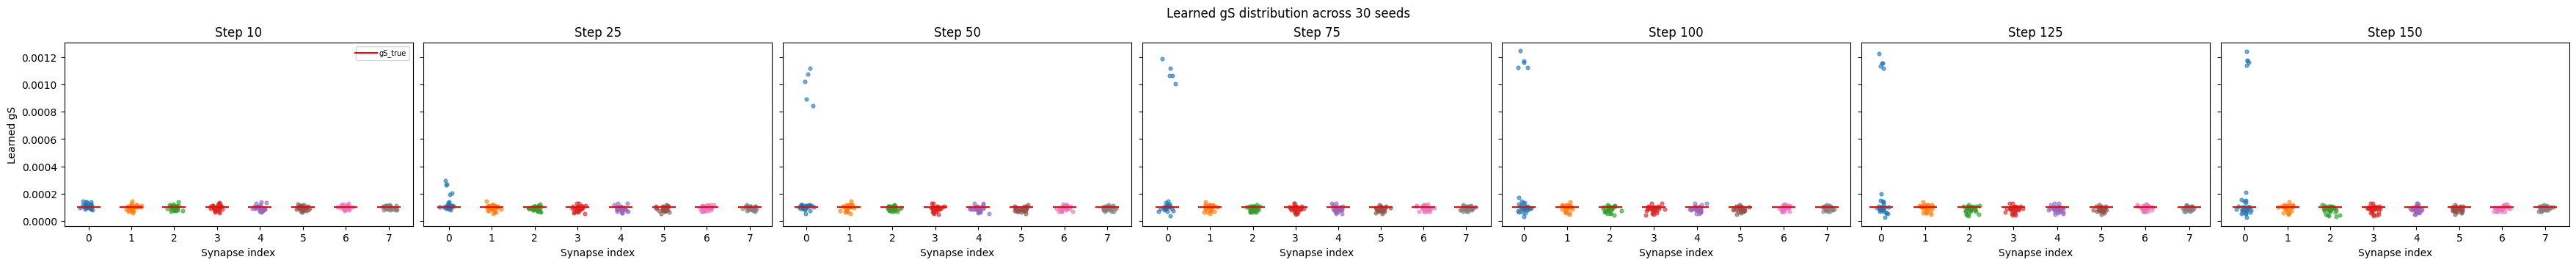

In [69]:
fig = plot_gS_ckpt(
    gS_ckpt=gS_ckpt_disk,
    gS_true=params_true[0]["IonotropicSynapse_gS"],
    checkpoints=checkpoints,
    S=30,
    Nsyn=Nsyn,
    logy=False
)

fig.savefig(outdir / "gS_ckpt.png", dpi=200, bbox_inches="tight")
fig.savefig(outdir / "gS_ckpt.pdf", bbox_inches="tight")
plt.show()

### Correlations 

In [100]:
def corr_ts_vs_scalar_over_seeds(X, y, eps=1e-12):
    X = np.asarray(X)
    y = np.asarray(y)

    assert X.shape[0] == y.shape[0], "Seed dimension mismatch"
    assert X.shape[1:-1] == y.shape[1:], f"Prefix dims mismatch: X {X.shape}, y {y.shape}"

    Xc = X - X.mean(axis=0, keepdims=True)
    yc = y - y.mean(axis=0, keepdims=True)

    num = np.sum(Xc * yc[..., None], axis=0)                       # (..., T)
    den = np.sqrt(np.sum(Xc**2, axis=0) * np.sum(yc**2, axis=0)[..., None] + eps)
    return num / den


def corr_Vsites_vs_grad(VALL, GRADS, eps=1e-12):
    V = np.asarray(VALL)
    G = np.asarray(GRADS)
    S, P, n_sites, T = V.shape
    assert G.shape == (S, P, G.shape[2]), "GRADS shape must be (S,P,Nsyn)"
    Nsyn = G.shape[2]

    Vc = V - V.mean(axis=0, keepdims=True)     # (S,P,n_sites,T)
    Gc = G - G.mean(axis=0, keepdims=True)     # (S,P,Nsyn)

    # numerator: sum_s Vc[s,p,j,t] * Gc[s,p,i] -> (P,j,i,t)
    num = np.einsum("spjt,spi->pjit", Vc, Gc)

    denV = np.sqrt(np.sum(Vc**2, axis=0) + eps)          # (P,n_sites,T)
    denG = np.sqrt(np.sum(Gc**2, axis=0) + eps)          # (P,Nsyn)
    den = denV[:, :, None, :] * denG[:, None, :, None]   # (P,n_sites,Nsyn,T)

    return num / den

In [101]:
def load_ckpt_dicts_from_seed_files(outdir, S, checkpoints):
    outdir = Path(outdir)

    # infer shapes from seed_000 + first checkpoint
    d0 = np.load(outdir / "seed_000.npz")
    c0 = checkpoints[0]
    P, n_sites, T = d0[f"VALL_{c0}"].shape
    P2, Nsyn = d0[f"GRADS_{c0}"].shape
    assert P == P2
    assert d0[f"JALL_{c0}"].shape == (P, T, Nsyn)

    VALL_ckpt = {c: np.zeros((S, P, n_sites, T), dtype=np.float32) for c in checkpoints}
    GRADS_ckpt = {c: np.zeros((S, P, Nsyn),       dtype=np.float32) for c in checkpoints}
    JALL_ckpt  = {c: np.zeros((S, P, T, Nsyn),    dtype=np.float32) for c in checkpoints}

    for s in range(S):
        d = np.load(outdir / f"seed_{s:03d}.npz")
        for c in checkpoints:
            VALL_ckpt[c][s]  = d[f"VALL_{c}"]
            GRADS_ckpt[c][s] = d[f"GRADS_{c}"]
            JALL_ckpt[c][s]  = d[f"JALL_{c}"]

    return VALL_ckpt, GRADS_ckpt, JALL_ckpt, (P, n_sites, T, Nsyn)

In [102]:
outdir = Path("outputs/onepat_167_S30_steps150")
S = 30
checkpoints = (10,25,50,75,100,125,150)

VALL_ckpt, GRADS_ckpt, JALL_ckpt, shapes = load_ckpt_dicts_from_seed_files(outdir, S, checkpoints)
print("Loaded shapes (P,n_sites,T,Nsyn):", shapes)

Loaded shapes (P,n_sites,T,Nsyn): (1, 8, 2001, 8)


In [103]:
targets_path = outdir / "targets_train.npy"
if targets_path.exists():
    targets_by_pattern = np.load(targets_path)   # (P,T)
else:
    targets_by_pattern = np.asarray(targets_train)  # fallback if still in memory
print("targets_by_pattern shape:", targets_by_pattern.shape)

targets_by_pattern shape: (1, 2001)


In [104]:
R_V = {}
for c in checkpoints:
    R_V[c] = corr_Vsites_vs_grad(VALL_ckpt[c], GRADS_ckpt[c])

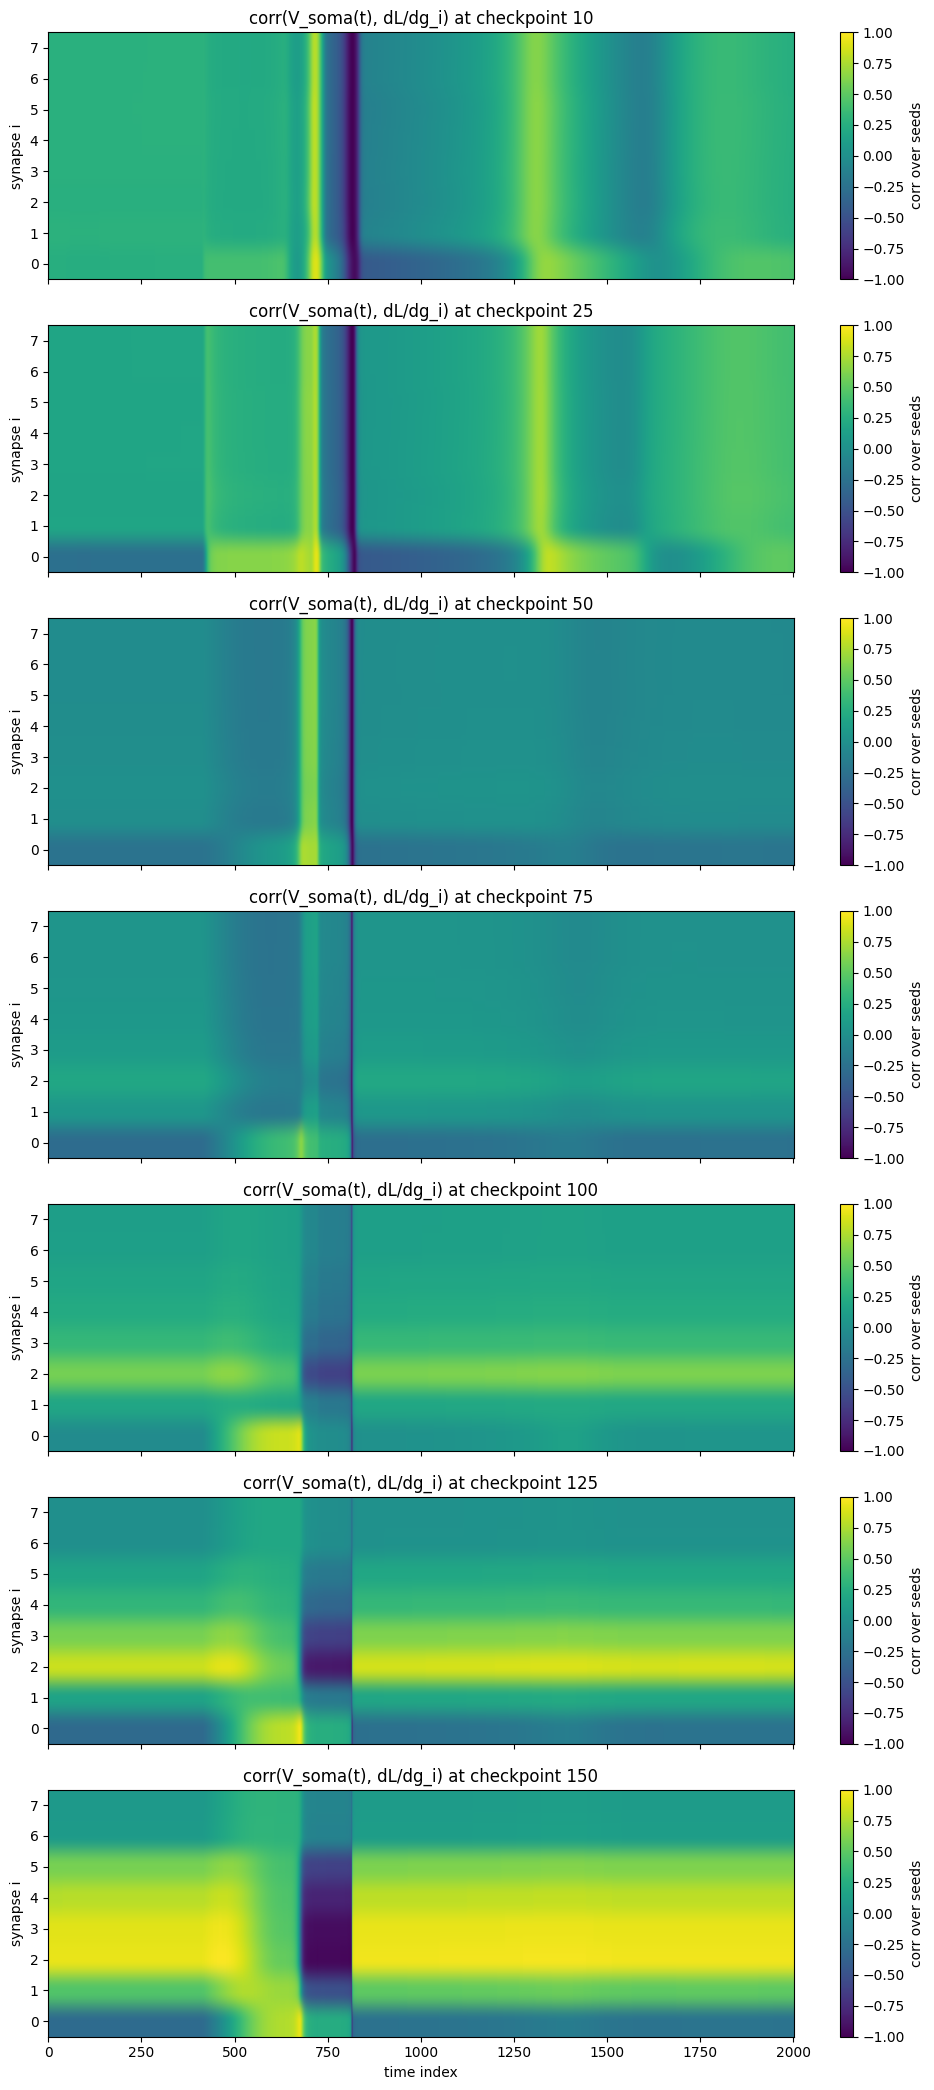

In [106]:
p = 0
n_ckpt = len(checkpoints)

fig, axes = plt.subplots(n_ckpt, 1, figsize=(10, 3 * n_ckpt), sharex=True)
if n_ckpt == 1:
    axes = [axes]

for i, c in enumerate(checkpoints):
    r_soma = R_V[c][p, 0, :, :]  # (Nsyn, T)  site 0 = soma
    ax = axes[i]
    im = ax.imshow(r_soma, aspect="auto", origin="lower", vmin=-1, vmax=1)
    fig.colorbar(im, ax=ax, label="corr over seeds")
    ax.set_ylabel("synapse i")
    ax.set_title(f"corr(V_soma(t), dL/dg_i) at checkpoint {c}")

axes[-1].set_xlabel("time index")
plt.tight_layout()
plt.show()

In [107]:
def corr_Vsites_vs_timeseries(VALL, TS, eps=1e-12):
    """
    VALL: (S,P,n_sites,T)
    TS:   (S,P,Nsyn,T)   (any per-synapse time series)
    returns: (P,n_sites,Nsyn,T) corr over seeds
    """
    V = np.asarray(VALL)
    Tser = np.asarray(TS)
    S, P, n_sites, T = V.shape
    assert Tser.shape[0] == S and Tser.shape[1] == P and Tser.shape[3] == T, (V.shape, Tser.shape)
    Nsyn = Tser.shape[2]

    Vc = V - V.mean(axis=0, keepdims=True)
    Tc = Tser - Tser.mean(axis=0, keepdims=True)

    num = np.einsum("spjt,spit->pjit", Vc, Tc)  # sum over seeds
    denV = np.sqrt(np.sum(Vc**2, axis=0) + eps)         # (P,n_sites,T)
    denT = np.sqrt(np.sum(Tc**2, axis=0) + eps)         # (P,Nsyn,T)
    den  = denV[:, :, None, :] * denT[:, None, :, :]    # (P,n_sites,Nsyn,T)
    return num / den

def corr_Vsites_vs_J(VALL, JALL, eps=1e-12):
    # JALL: (S,P,T,Nsyn) -> (S,P,Nsyn,T)
    Jt = np.transpose(np.asarray(JALL), (0,1,3,2))
    return corr_Vsites_vs_timeseries(VALL, Jt, eps=eps)

In [111]:
def corr_Vsites_vs_contrib(VALL, targets, JALL, eps=1e-12):
    V = np.asarray(VALL)                 # (S,P,n_sites,T)
    tgt = np.asarray(targets)            # (P,T)
    J = np.asarray(JALL)                 # (S,P,T,Nsyn)

    S, P, n_sites, T = V.shape
    assert tgt.shape == (P, T)

    V_soma = V[:, :, 0, :]                               # (S,P,T)
    dL_dV  = (2.0 / T) * (V_soma - tgt[None, :, :])      # (S,P,T)

    contrib = dL_dV[:, :, :, None] * J                   # (S,P,T,Nsyn)
    contrib = np.transpose(contrib, (0,1,3,2))           # (S,P,Nsyn,T)

    return corr_Vsites_vs_timeseries(V, contrib, eps=eps)

In [112]:
R_VJ = {}
for c in checkpoints:
    R_VJ[c] = corr_Vsites_vs_J(VALL_ckpt[c], JALL_ckpt[c])

In [113]:
R_Vcontrib = {}

for c in checkpoints:
    R_Vcontrib[c] = corr_Vsites_vs_contrib(VALL_ckpt[c], targets_by_pattern, JALL_ckpt[c])
    print(c, R_Vcontrib[c].shape)

10 (1, 8, 8, 2001)
25 (1, 8, 8, 2001)
50 (1, 8, 8, 2001)
75 (1, 8, 8, 2001)
100 (1, 8, 8, 2001)
125 (1, 8, 8, 2001)
150 (1, 8, 8, 2001)


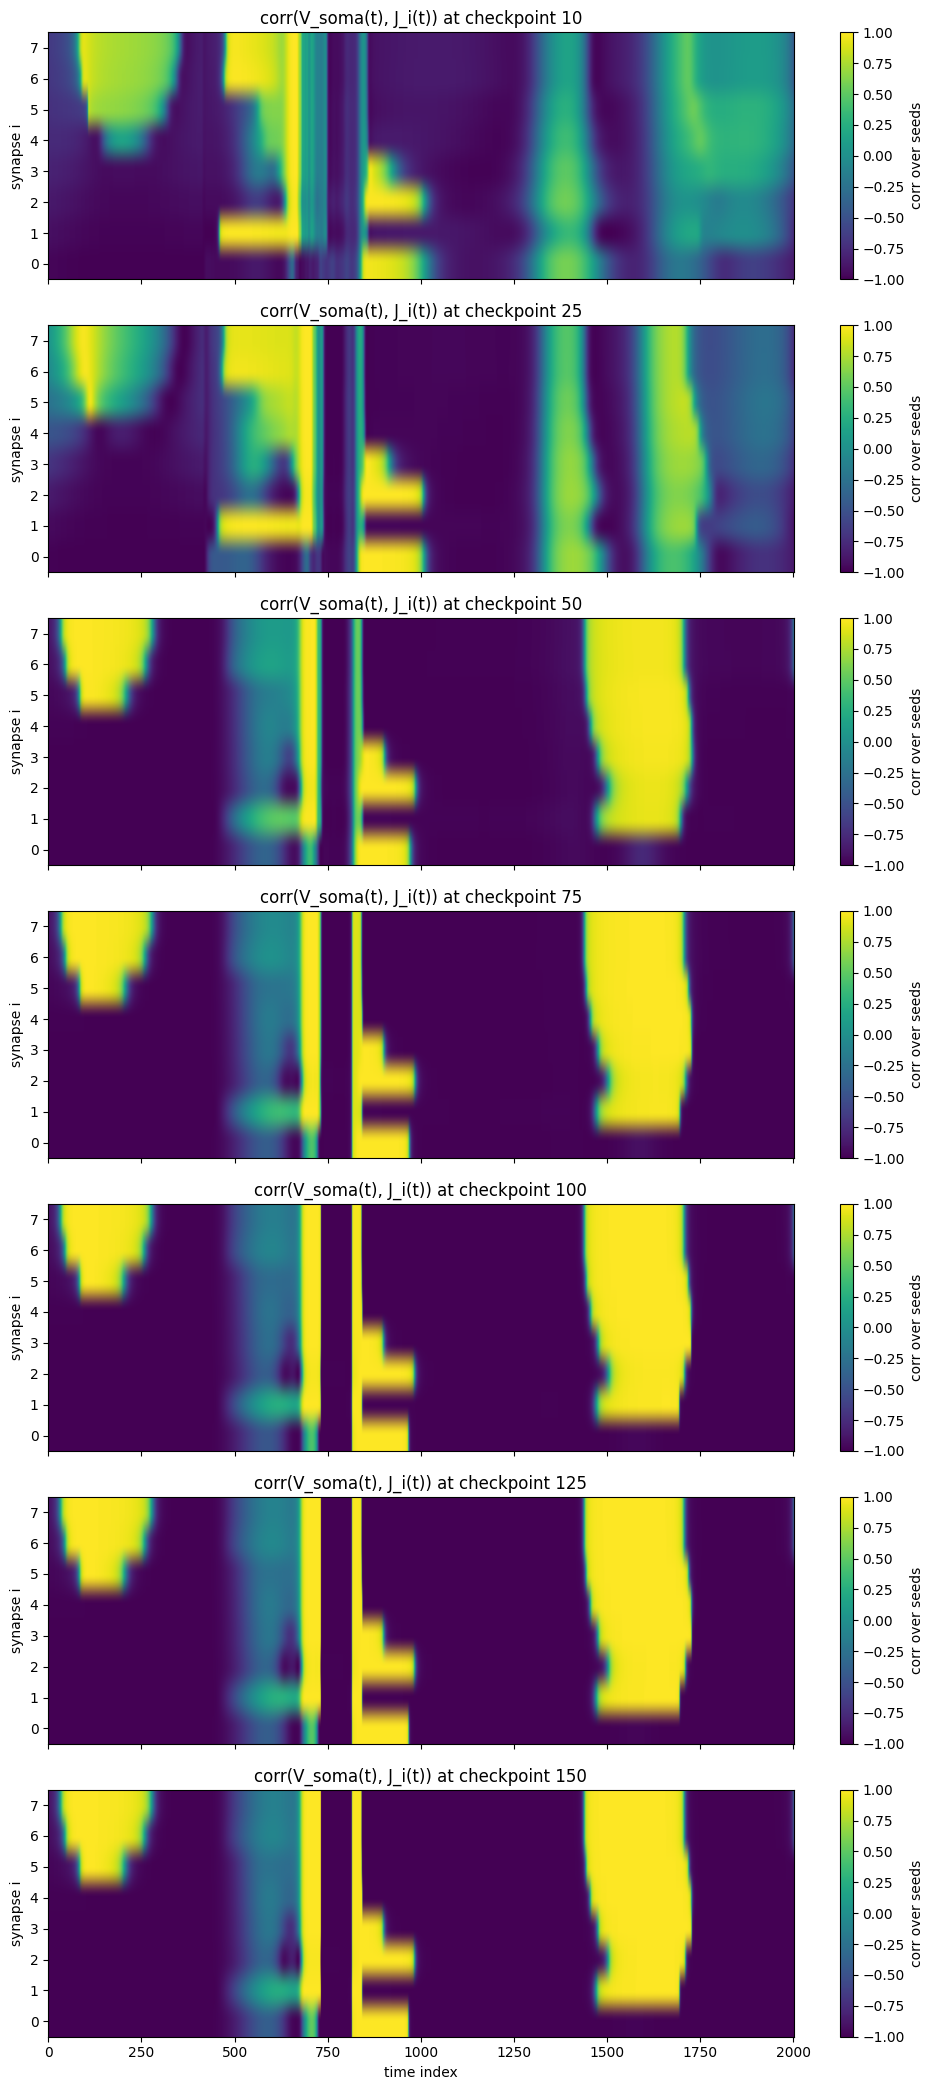

In [114]:
p = 0
n_ckpt = len(checkpoints)

fig, axes = plt.subplots(n_ckpt, 1, figsize=(10, 3 * n_ckpt), sharex=True)
if n_ckpt == 1:
    axes = [axes]

for i, c in enumerate(checkpoints):
    r_soma = R_VJ[c][p, 0, :, :]  # (Nsyn, T) site 0 = soma
    ax = axes[i]
    im = ax.imshow(r_soma, aspect="auto", origin="lower", vmin=-1, vmax=1)
    fig.colorbar(im, ax=ax, label="corr over seeds")
    ax.set_ylabel("synapse i")
    ax.set_title(f"corr(V_soma(t), J_i(t)) at checkpoint {c}")

axes[-1].set_xlabel("time index")
plt.tight_layout()
plt.show()

In [115]:
print(R_VJ[checkpoints[0]].shape)      # expect (P, n_sites, Nsyn, T)
print(R_V_ckpt[checkpoints[0]].shape)  # expect same shape

(1, 8, 8, 2001)
(1, 8, 8, 2001)


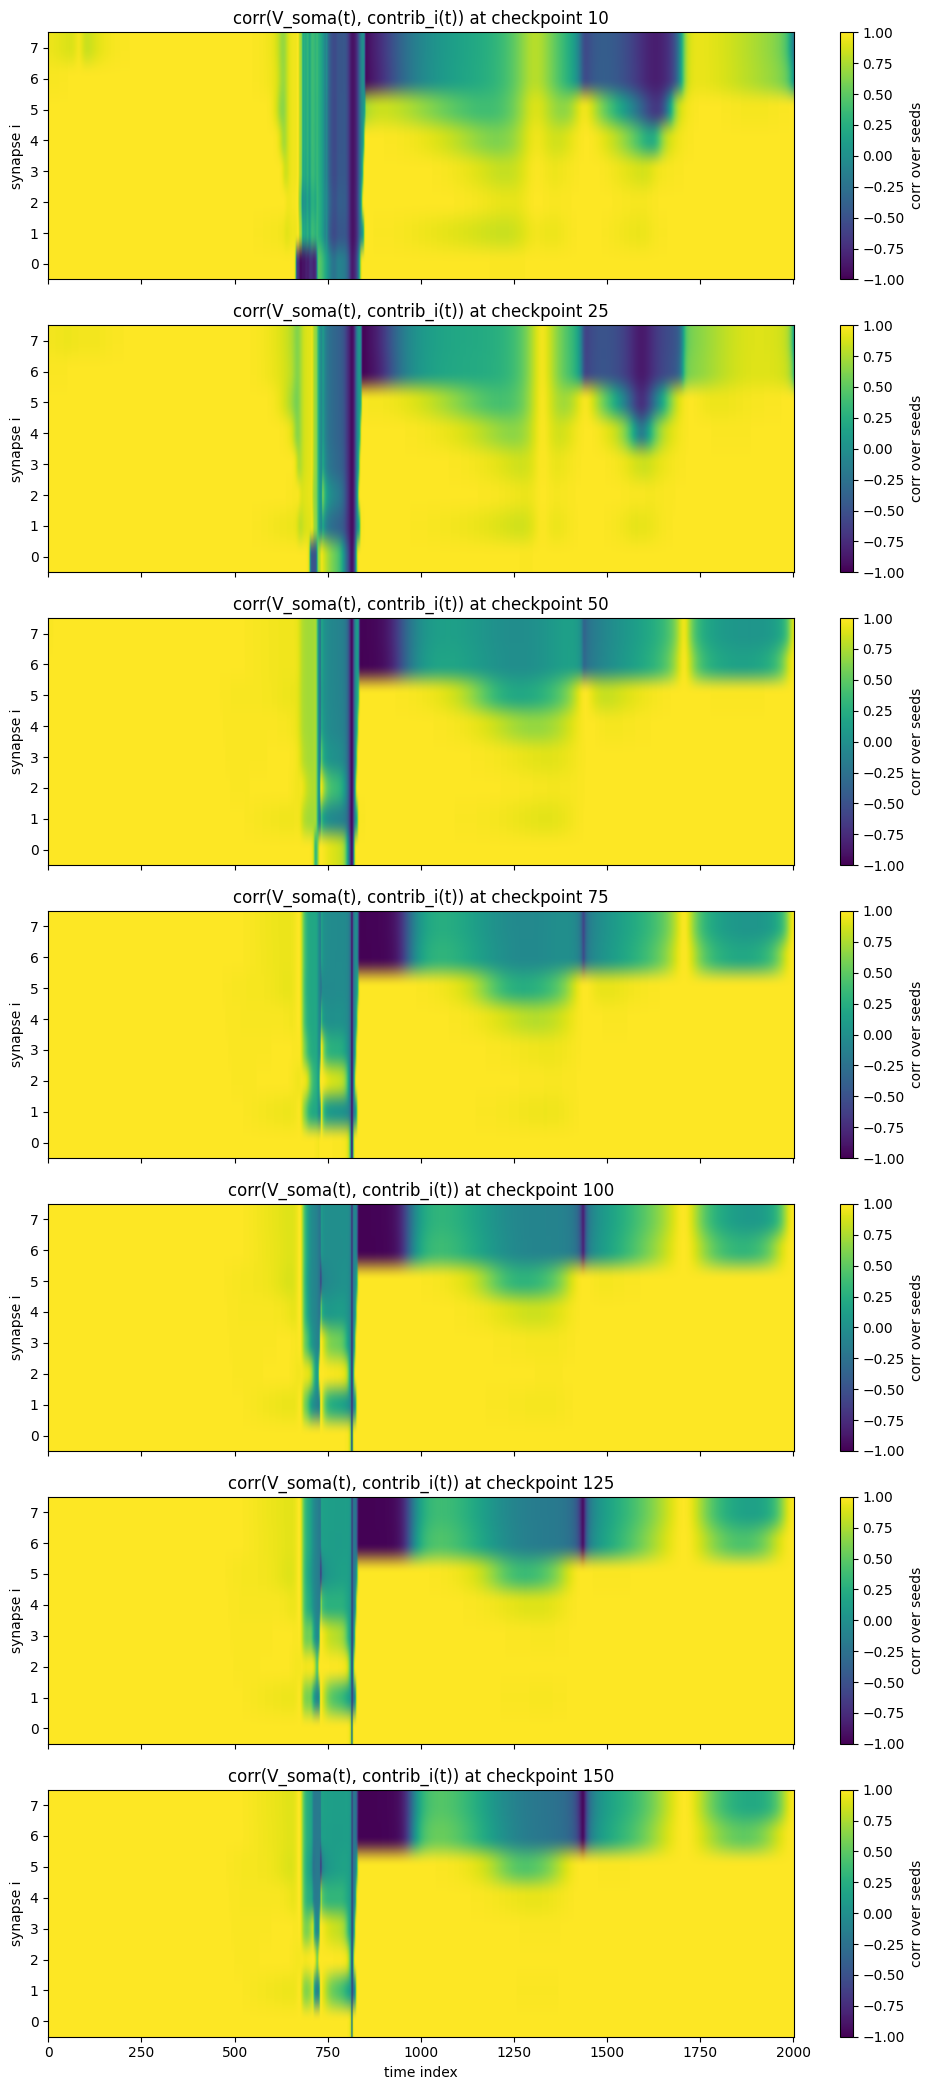

In [116]:
p = 0
n_ckpt = len(checkpoints)

fig, axes = plt.subplots(n_ckpt, 1, figsize=(10, 3 * n_ckpt), sharex=True)
if n_ckpt == 1:
    axes = [axes]

for i, c in enumerate(checkpoints):
    r_soma = R_Vcontrib[c][p, 0, :, :]  # (Nsyn, T) site 0 = soma
    ax = axes[i]
    im = ax.imshow(r_soma, aspect="auto", origin="lower", vmin=-1, vmax=1)
    fig.colorbar(im, ax=ax, label="corr over seeds")
    ax.set_ylabel("synapse i")
    ax.set_title(f"corr(V_soma(t), contrib_i(t)) at checkpoint {c}")  # <-- fixed

axes[-1].set_xlabel("time index")
plt.tight_layout()
plt.show()

In [117]:
c = checkpoints[-1]
print("std V_soma @t across seeds:", VALL_ckpt[c][:, 0, 0, :].std())
print("std J @t across seeds:", JALL_ckpt[c][:, 0, :, :].std())

std V_soma @t across seeds: 13.938349
std J @t across seeds: 1162361.2


In [118]:
c = checkpoints[-1]
J = JALL_ckpt[c]  # (S,P,T,Nsyn)

print("J abs max:", np.max(np.abs(J)))
print("J abs p99 :", np.percentile(np.abs(J), 99))
print("J abs p50 :", np.percentile(np.abs(J), 50))

J abs max: 37371464.0
J abs p99 : 4899005.4799999995
J abs p50 : 520.3556823730469


In [119]:
c = checkpoints[-1]
J = JALL_ckpt[c]   # (S,P,T,Nsyn)

print("all finite?", np.isfinite(J).all())

# max per seed (collapse over P,T,Nsyn)
seed_max = np.max(np.abs(J), axis=(1,2,3))
print("top seeds by |J|:", np.argsort(seed_max)[-5:][::-1], seed_max[np.argsort(seed_max)[-5:][::-1]])

# find the single largest entry and its index (seed, pattern, time, synapse)
flat_idx = np.argmax(np.abs(J))
idx = np.unravel_index(flat_idx, J.shape)
print("argmax |J| index (s,p,t,i):", idx, "value:", J[idx])

all finite? True
top seeds by |J|: [18 23 22 12 10] [37371464. 37210220. 37184944. 37147188. 36608500.]
argmax |J| index (s,p,t,i): (18, 0, 722, 7) value: 37371464.0


In [120]:
def clip_over_seeds(TS, p=99.0):
    """
    TS: (S,P,Nsyn,T) time series
    clips over the seed axis separately for each (P,Nsyn,T)
    """
    thr = np.percentile(np.abs(TS), p, axis=0, keepdims=True)   # (1,P,Nsyn,T)
    return np.clip(TS, -thr, thr)

def corr_Vsites_vs_timeseries(VALL, TS, eps=1e-12):
    """
    VALL: (S,P,n_sites,T)
    TS:   (S,P,Nsyn,T)
    returns (P,n_sites,Nsyn,T) corr over seeds
    """
    V = np.asarray(VALL)
    TS = np.asarray(TS)

    Vc = V - V.mean(axis=0, keepdims=True)
    Tc = TS - TS.mean(axis=0, keepdims=True)

    num = np.einsum("spjt,spit->pjit", Vc, Tc)
    denV = np.sqrt(np.sum(Vc**2, axis=0) + eps)          # (P,n_sites,T)
    denT = np.sqrt(np.sum(Tc**2, axis=0) + eps)          # (P,Nsyn,T)
    den  = denV[:, :, None, :] * denT[:, None, :, :]
    return num / den

def corr_Vsites_vs_J(VALL, JALL, clip_p=None):
    # JALL: (S,P,T,Nsyn) -> TS: (S,P,Nsyn,T)
    TS = np.transpose(np.asarray(JALL), (0,1,3,2))
    if clip_p is not None:
        TS = clip_over_seeds(TS, p=clip_p)
    return corr_Vsites_vs_timeseries(VALL, TS)

In [121]:
c = checkpoints[-1]
R_raw  = corr_Vsites_vs_J(VALL_ckpt[c], JALL_ckpt[c], clip_p=None)
R_clip = corr_Vsites_vs_J(VALL_ckpt[c], JALL_ckpt[c], clip_p=99.0)

# Look at soma site, pattern 0: (Nsyn,T)
p = 0
raw_map  = R_raw[p, 0, :, :]
clip_map = R_clip[p, 0, :, :]

print("max |diff|:", np.max(np.abs(raw_map - clip_map)))
print("mean |diff|:", np.mean(np.abs(raw_map - clip_map)))

max |diff|: 0.04266524454381018
mean |diff|: 0.0015958875320401175


In [ ]:
import os, time
from pathlib import Path

SCRATCH = Path(os.environ["SCRATCH"])     # /n/netscratch
HOME    = Path(os.environ["HOME"])       # /n/home12/isanchez

run_id = f"spike16_3hot_S{S}_steps{max(checkpoints)}_{time.strftime('%Y%m%d_%H%M%S')}"
# Big stuff to scratch
outdir_scratch = SCRATCH / "isanchez" / "jaxneuro" / "runs" / run_id
outdir_scratch.mkdir(parents=True, exist_ok=True)

# Optional: small “final” dir in home
outdir_home = HOME / "jaxneuro" / "outputs" / run_id
outdir_home.mkdir(parents=True, exist_ok=True)

print("SCRATCH outdir:", outdir_scratch)
print("HOME outdir:", outdir_home)

In [ ]:
def has_somatic_ap(v_soma: jnp.ndarray, dt: float,
                   v_overshoot_th: float = 0.0,
                   dvdt_th: float = 30.0,
                   v_floor_for_dvdt: float = -20.0) -> jnp.bool_:
    # condition A: overshoot
    overshoot = jnp.any(v_soma >= v_overshoot_th)

    # condition B: fast upstroke + sufficiently depolarized
    dvdt = jnp.diff(v_soma) / dt  # mV/ms
    fast_up = jnp.any((dvdt >= dvdt_th) & (v_soma[1:] >= v_floor_for_dvdt))

    return overshoot | fast_up

batched_has_somatic_ap = jit(vmap(has_somatic_ap, in_axes=(0, None, None, None, None)))

In [ ]:
def patterns_of_weight_k(N, k, dtype=np.float64):
    pats = []
    from itertools import combinations
    for comb in combinations(range(N), k):
        p = np.zeros((N,), dtype=dtype)
        p[list(comb)] = 1.0
        pats.append(p)
    return jnp.asarray(np.stack(pats, axis=0))

patterns_3hot = patterns_of_weight_k(Nsyn, 3)   # (56, 8)
print("patterns_3hot shape:", patterns_3hot.shape)

# ---- simulate soma for all 3-hot patterns
targets_3hot = batched_simulate_soma(params_true, patterns_3hot)  # (56, T)
T = targets_3hot.shape[1]
t_arr = np.arange(T_keep) * dt

print("targets_3hot shape:", targets_3hot.shape)

# ---- (optional) compute which 3-hot patterns cause somatic AP (using your AP detector)
ap_3hot = jnp.array([has_somatic_ap(targets_3hot[i], dt) for i in range(targets_3hot.shape[0])])
print(f"# somatic APs in 3-hot set: {int(ap_3hot.sum())} / {targets_3hot.shape[0]}")

# ---- plot: overlay all traces (AP ones thicker)
fig, ax = plt.subplots(figsize=(9, 3.5))

for i in range(targets_3hot.shape[0]):
    if bool(ap_3hot[i]):
        ax.plot(t_arr, np.array(targets_3hot[i]), alpha=0.9, lw=1.5)
    else:
        ax.plot(t_arr, np.array(targets_3hot[i]), alpha=0.15, lw=1.0)

ax.axvspan(i_delay, i_delay + i_dur, color="gold", alpha=0.2, label="stim window")
ax.set_ylim(-80, 80)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("V_soma (mV)")
ax.set_title("Teacher soma traces for all 56 three-hot patterns (thick = AP)")
plt.tight_layout()
plt.show()

# ---- (optional) show which 3-hot patterns spiked (by indices)
spiking_idx = np.where(np.array(ap_3hot, dtype=bool))[0]
print("Spiking 3-hot pattern indices:", spiking_idx)

# print the actual active synapse indices for each spiking pattern
for i in spiking_idx[:]:  # show first 10
    on = np.where(np.array(patterns_3hot[i]) > 0.5)[0]
    print(f"pattern {i}: on synapses {on}")

In [ ]:
# # If you already have ap_3hot:
# spiking_idx = np.where(np.array(ap_3hot, dtype=bool))[0]

# print("num spiking:", len(spiking_idx))
# print("spiking_idx:", spiking_idx)

# # Take exactly 16 spiking patterns
# assert len(spiking_idx) >= 16, "Not enough spiking patterns found."
# spiking_idx16 = spiking_idx[:16]

# patterns_train = patterns_3hot[spiking_idx16]     # (16, Nsyn)
# print("patterns_train shape:", patterns_train.shape)

# # Optional: print which synapses are ON in each
# for k, idx in enumerate(spiking_idx16):
#     on = np.where(np.array(patterns_3hot[idx]) > 0.5)[0]
#     print(f"train pattern {k:02d} (orig {idx:02d}): ON synapses {on}")

In [ ]:
import numpy as np

spiking_idx = np.where(np.array(ap_3hot, dtype=bool))[0]
assert len(spiking_idx) >= 6

def on_set(pat):
    return tuple(np.where(np.array(pat) > 0.5)[0].tolist())

# collect spiking ON-sets
spike_sets = [(idx, on_set(patterns_3hot[idx])) for idx in spiking_idx]

picked = []
used_pairs = set()

for idx, sset in spike_sets:
    # all 2-of-3 pairs in this 3-hot
    pairs = {(sset[a], sset[b]) for a in range(3) for b in range(a+1, 3)}
    # only pick if it adds new pair structure
    if len(used_pairs.intersection(pairs)) <= 1:  # allow a little overlap
        picked.append(idx)
        used_pairs |= pairs
    if len(picked) == 6:
        break

# fallback if diversity rule was too strict
if len(picked) < 6:
    for idx in spiking_idx:
        if idx not in picked:
            picked.append(idx)
        if len(picked) == 6:
            break

spiking_idx6 = np.array(picked, dtype=int)
patterns_train = patterns_3hot[spiking_idx6]

print("picked spiking indices:", spiking_idx6)
print("patterns_train shape:", patterns_train.shape)

for k, idx in enumerate(spiking_idx6):
    on = np.where(np.array(patterns_3hot[idx]) > 0.5)[0]
    print(f"train pattern {k:02d} (orig {idx:02d}): ON synapses {on}")

In [ ]:
targets_train = batched_simulate_soma(params_true, patterns_train)  # (16, T_keep)
print("targets_train shape:", targets_train.shape)

In [ ]:
# Compare teacher soma from your training forward vs batched_simulate_soma for a couple patterns
params_true_phys = [{"IonotropicSynapse_gS": params_true[0]["IonotropicSynapse_gS"]}]

pred_train = batched_soma_train(params_true_phys, patterns_train[:2])   # (2,T)
pred_other = batched_simulate_soma(params_true, patterns_train[:2])     # (2,T)

print("max abs diff:", float(np.max(np.abs(np.asarray(pred_train) - np.asarray(pred_other)))))

In [ ]:
def run_many_seeds_one_pattern_save_per_seed(
    S,
    patterns_train,
    targets_train,
    *,
    checkpoints=(10,25,50,75,100),
    n_steps=None,
    outdir=None,
    resume=True,
    keep_in_memory=True,
):
    P = patterns_train.shape[0]
    if n_steps is None:
        n_steps = int(max(checkpoints))

    if outdir is None:
        outdir = make_run_dir(run_name=f"onepat_167_S{S}_steps{n_steps}")
    else:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)

    np.save(outdir / "patterns_train.npy", np.asarray(patterns_train, dtype=np.float32))  # (P,Nsyn)
    np.save(outdir / "targets_train.npy",  np.asarray(targets_train,  dtype=np.float32))  # (P,T)
    
    meta = dict(
        S=int(S),
        P=int(patterns_train.shape[0]),
        Nsyn=int(Nsyn),
        checkpoints=list(checkpoints),
        n_steps=int(n_steps),
        dt=float(dt),
        T_keep=int(T_keep),
        patterns_file="patterns_train.npy",
        targets_file="targets_train.npy",
        meta["spiking_idx_all"] = spiking_idx.tolist()
        meta["spiking_idx16"] = spiking_idx16.tolist()
    )
    with open(outdir / "meta.json", "w") as f:
        json.dump(meta, f, indent=2)
        
    # determine n_sites once
    tmp_tr = batched_all_train([{"IonotropicSynapse_gS": params_true[0]["IonotropicSynapse_gS"]}], patterns_train)
    n_sites = int(tmp_tr.shape[1])

    # keep full arrays in RAM
    if keep_in_memory:
        VALL_ckpt = {c: np.zeros((S, P, n_sites, T_keep), dtype=np.float32) for c in checkpoints}
        LOSS_ckpt = {c: np.zeros((S, P),               dtype=np.float32) for c in checkpoints}
        GRADS_ckpt = {c: np.zeros((S, P, Nsyn),        dtype=np.float32) for c in checkpoints}
        JALL_ckpt = {c: np.zeros((S, P, T_keep, Nsyn), dtype=np.float32) for c in checkpoints}
        GRADFACT_ckpt = {c: np.zeros((S, P, Nsyn),     dtype=np.float32) for c in checkpoints}
        gS_ckpt = {c: np.zeros((S, Nsyn),              dtype=np.float32) for c in checkpoints}
        RELERR_ckpt = {c: np.zeros((S,),               dtype=np.float32) for c in checkpoints}
        train_logs = [None] * S
    else:
        VALL_ckpt = LOSS_ckpt = GRADS_ckpt = JALL_ckpt = None
        GRADFACT_ckpt = gS_ckpt = RELERR_ckpt = None
        train_logs = None

    print(f"\nSaving per-seed files to: {outdir}")
    print(f"S={S}, checkpoints={checkpoints}, steps={n_steps}, P={P}, n_sites={n_sites}, T={T_keep}\n")

    for s in range(S):
        seed_path = outdir / f"seed_{s:03d}.npz"
        log_path  = outdir / f"seed_{s:03d}_log.json"

        if resume and seed_path.exists():
            print(f"seed {s:3d}: exists -> skip")
            # if keeping in memory, you can also load it back in here
            continue

        # train this seed
        ckpt_params_s, final_params_s, log_s = train_one_seed_adaptive(
            s, patterns_train, targets_train,
            checkpoints=checkpoints,
            loss_tol=-1.0,
            max_steps=n_steps,
            chunk_steps=n_steps,
            log_every=max(1, n_steps // 5),
        )

        # compute and store arrays for this seed (across checkpoints)
        save_dict = {}
        for c in checkpoints:
            params_c = ckpt_params_s[c]
            ev = eval_params_on_patterns(params_c, patterns_train, targets_train)

            save_dict[f"gS_{c}"]       = np.asarray(ev["gS_vec"], dtype=np.float32)              # (Nsyn,)
            save_dict[f"VALL_{c}"]     = np.asarray(ev["traces_all"], dtype=np.float32)         # (P,n_sites,T)
            save_dict[f"LOSS_{c}"]     = np.asarray(ev["losses"], dtype=np.float32)             # (P,)
            save_dict[f"GRADS_{c}"]    = np.asarray(ev["grad_full"], dtype=np.float32)          # (P,Nsyn)
            save_dict[f"JALL_{c}"]     = np.asarray(ev["J"], dtype=np.float32)                  # (P,T,Nsyn)
            save_dict[f"GRADFACT_{c}"] = np.asarray(ev["grad_fact"], dtype=np.float32)          # (P,Nsyn)
            save_dict[f"RELERR_{c}"]   = np.asarray(float(ev["max_rel_err"]), dtype=np.float32) # scalar

            # if also keeping in memory, fill the big arrays
            if keep_in_memory:
                gS_ckpt[c][s]        = save_dict[f"gS_{c}"]
                VALL_ckpt[c][s]      = save_dict[f"VALL_{c}"]
                LOSS_ckpt[c][s]      = save_dict[f"LOSS_{c}"]
                GRADS_ckpt[c][s]     = save_dict[f"GRADS_{c}"]
                JALL_ckpt[c][s]      = save_dict[f"JALL_{c}"]
                GRADFACT_ckpt[c][s]  = save_dict[f"GRADFACT_{c}"]
                RELERR_ckpt[c][s]    = float(save_dict[f"RELERR_{c}"])

        # save seed file atomically (crash-safe)
        atomic_save_npz(seed_path, **save_dict)

        # save log as json
        with open(log_path, "w") as f:
            json.dump(log_s, f, indent=2)

        if keep_in_memory:
            train_logs[s] = log_s

        print(f"seed {s:3d}: saved {seed_path.name}")

    if keep_in_memory:
        return dict(
            VALL_ckpt=VALL_ckpt,
            LOSS_ckpt=LOSS_ckpt,
            GRADS_ckpt=GRADS_ckpt,
            JALL_ckpt=JALL_ckpt,
            GRADFACT_ckpt=GRADFACT_ckpt,
            gS_ckpt=gS_ckpt,
            RELERR_ckpt=RELERR_ckpt,
            train_logs=train_logs,
            outdir=str(outdir),
        )
    else:
        return dict(outdir=str(outdir))

In [ ]:
S = 
checkpoints = (10, 25, 50, 75, 100)

out = run_many_seeds_one_pattern_save_per_seed(
    S, patterns_train, targets_train,
    checkpoints=checkpoints,
    keep_in_memory=True,  
    resume=True,
    outdir=outdir_scratch,  # strongly recommended on the cluster
)
print("run dir:", out["outdir"])

In [ ]:
P = patterns_train.shape[0]  # 6

# n_sites you can get once:
tmp_tr = batched_all_train([{"IonotropicSynapse_gS": params_true[0]["IonotropicSynapse_gS"]}], patterns_train)
n_sites = int(tmp_tr.shape[1])

out_merged = merge_seed_files(
    outdir=out["outdir"],
    S=S,
    checkpoints=checkpoints,
    P=P,
    n_sites=n_sites,
    T_keep=T_keep,
    Nsyn=Nsyn
)

In [ ]:
R_V_ckpt, R_J_ckpt, R_contrib_ckpt = compute_all_correlations(
    checkpoints,
    VALL_ckpt=out_merged["VALL_ckpt"],
    GRADS_ckpt=out_merged["GRADS_ckpt"],
    JALL_ckpt=out_merged["JALL_ckpt"],
    targets_by_pattern=targets_train,   # (P,T)
)